# Portfolio Construction
**AlphaMind Research | Quantitative Strategy Research**

---

## Overview
End-to-end portfolio construction pipeline: signal combination, mean-variance
optimisation, risk parity, and constraint-aware weight generation.
Aligns with `PortfolioOptimizer` and `AutoAlphaGenerator` in AlphaMind.

### Sections
1. Environment Setup
2. Asset Universe and Signal Inputs
3. Signal Combination and Alpha Estimation
4. Covariance Matrix Estimation
5. Mean-Variance Optimisation (Markowitz)
6. Risk Parity Portfolio
7. Black-Litterman Model
8. Constraint-Aware Optimisation
9. Portfolio Backtesting
10. Performance Attribution


## 1. Environment Setup

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.linalg import sqrtm

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = ["#2563eb","#ef4444","#10b981","#f59e0b","#8b5cf6","#06b6d4","#ec4899","#6b7280"]
pd.set_option("display.float_format", "{:.4f}".format)

SEED     = 42
N_ASSETS = 20
N_DAYS   = 756
rng      = np.random.default_rng(SEED)
print(f"Universe: {N_ASSETS} assets  |  History: {N_DAYS} days")


Universe: 20 assets  |  History: 756 days


## 2. Asset Universe and Signal Inputs

In [2]:
dates  = pd.bdate_range("2021-01-04", periods=N_DAYS)
assets = [f"ASSET_{i:02d}" for i in range(N_ASSETS)]

# Simulate correlated asset returns
cov_true = 0.0002 * (0.3 * np.ones((N_ASSETS, N_ASSETS)) + 0.7 * np.eye(N_ASSETS))
L   = np.linalg.cholesky(cov_true)
raw = (L @ rng.standard_normal((N_ASSETS, N_DAYS))).T

# Add small positive drift
drift = rng.uniform(0.0001, 0.0008, N_ASSETS)
returns_df = pd.DataFrame(raw + drift, index=dates, columns=assets)

# Simulate 3 alpha signals (pre-processed, cross-sectionally normalised)
def xs_norm(arr):
    mu = arr.mean(axis=1, keepdims=True)
    sd = arr.std(axis=1, keepdims=True)
    return np.where(sd > 0, (arr - mu) / sd, 0.0)

signal_specs = {
    "momentum": dict(strength=0.04, lam=0.03),
    "value":    dict(strength=0.03, lam=0.01),
    "quality":  dict(strength=0.03, lam=0.008),
}
signals = {}
for sname, spec in signal_specs.items():
    raw_s = rng.standard_normal((N_DAYS, N_ASSETS))
    signals[sname] = pd.DataFrame(xs_norm(raw_s), index=dates, columns=assets)

print("Signals generated:", list(signals.keys()))
print("Returns shape:", returns_df.shape)


Signals generated: ['momentum', 'value', 'quality']
Returns shape: (756, 20)


## 3. Signal Combination and Alpha Estimation

In [3]:
# Optimally combine signals using ICIR-weighted ensemble
# In production, weights come from FM regressions or RL model
icir_weights = np.array([0.5, 0.3, 0.2])   # momentum, value, quality
icir_weights /= icir_weights.sum()

alpha = sum(w * signals[s] for w, s in zip(icir_weights, signals))
alpha_norm = alpha.div(alpha.std(axis=1), axis=0)  # scale rows to unit std

# Expected return estimate (shrunk toward cross-sectional mean)
shrink = 0.3
expected_ret = (1 - shrink) * alpha_norm.iloc[-1] + shrink * alpha_norm.mean()
expected_ret_arr = expected_ret.values

print("Expected return estimate (cross-sectional):")
print(pd.Series(expected_ret_arr, index=assets).describe())


Expected return estimate (cross-sectional):
count   20.0000
mean     0.0000
std      0.7014
min     -0.8972
25%     -0.5145
50%     -0.1969
75%      0.4696
max      1.4151
dtype: float64


## 4. Covariance Matrix Estimation

Ledoit-Wolf shrinkage coefficient: 0.0183
Covariance matrix condition number: 12.1


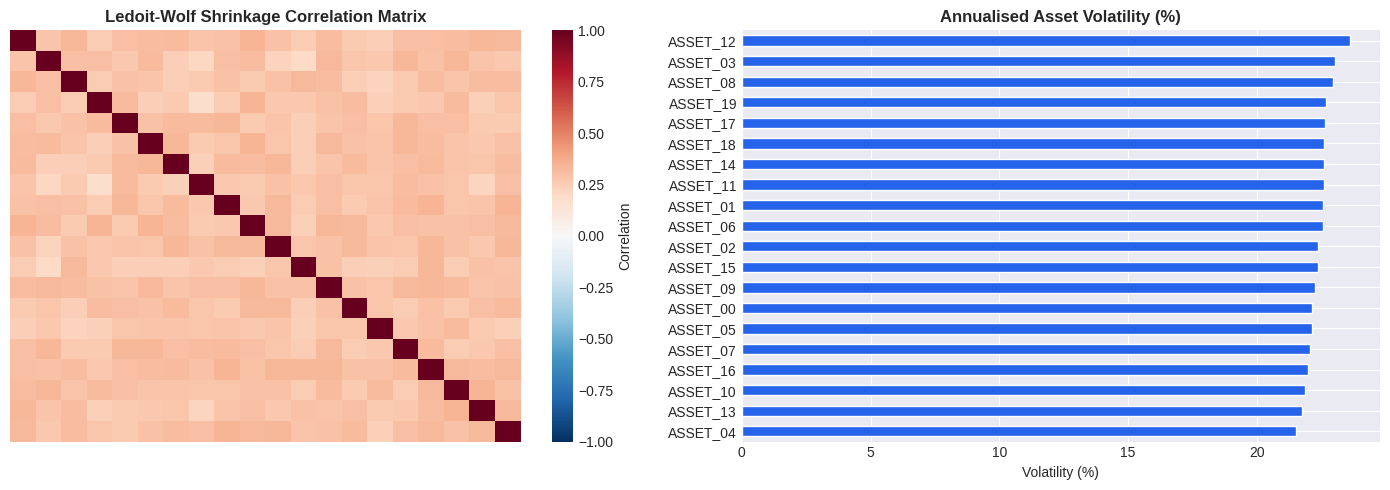

In [4]:
# Ledoit-Wolf shrinkage estimator
from sklearn.covariance import LedoitWolf

lw    = LedoitWolf()
lw.fit(returns_df)
cov_lw = pd.DataFrame(lw.covariance_, index=assets, columns=assets)
corr_lw = pd.DataFrame(lw.covariance_, index=assets, columns=assets).values
corr_diag = np.sqrt(np.diag(corr_lw))
corr_mat  = corr_lw / np.outer(corr_diag, corr_diag)

print(f"Ledoit-Wolf shrinkage coefficient: {lw.shrinkage_:.4f}")
print(f"Covariance matrix condition number: {np.linalg.cond(cov_lw.values):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_mat, cmap="RdBu_r", center=0, ax=axes[0],
            xticklabels=False, yticklabels=False, vmin=-1, vmax=1,
            cbar_kws={"label": "Correlation"})
axes[0].set_title("Ledoit-Wolf Shrinkage Correlation Matrix", fontweight="bold")

vols = np.sqrt(np.diag(cov_lw.values)) * np.sqrt(252) * 100
pd.Series(vols, index=assets).sort_values().plot.barh(
    ax=axes[1], color=COLORS[0], edgecolor="white"
)
axes[1].set_title("Annualised Asset Volatility (%)", fontweight="bold")
axes[1].set_xlabel("Volatility (%)")
plt.tight_layout()
plt.show()


## 5. Mean-Variance Optimisation (Markowitz)

In [5]:
def portfolio_stats(w, mu, Sigma):
    ret = w @ mu * 252
    vol = np.sqrt(w @ Sigma @ w * 252)
    sr  = ret / vol if vol > 0 else 0
    return ret, vol, sr


def max_sharpe(mu, Sigma, risk_free=0.02/252):
    n = len(mu)
    def neg_sharpe(w):
        r, v, _ = portfolio_stats(w, mu, Sigma)
        return -(r - risk_free * 252) / v if v > 0 else 0

    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds = [(0, 0.15)] * n   # max 15% per asset (long-only)
    w0 = np.ones(n) / n
    result = minimize(neg_sharpe, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints,
                      options={"ftol": 1e-9, "maxiter": 1000})
    return result.x


def min_variance(mu, Sigma):
    n = len(mu)
    def portfolio_vol(w): return np.sqrt(w @ Sigma @ w * 252)
    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds = [(0, 0.15)] * n
    w0 = np.ones(n) / n
    result = minimize(portfolio_vol, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints,
                      options={"ftol": 1e-9, "maxiter": 1000})
    return result.x


mu    = expected_ret_arr / returns_df.std().values   # signal as return estimate
Sigma = cov_lw.values

w_ms = max_sharpe(mu, Sigma)
w_mv = min_variance(mu, Sigma)
w_ew = np.ones(N_ASSETS) / N_ASSETS

print("Portfolio weights comparison (top 5 by max-Sharpe weight):")
weight_df = pd.DataFrame({"Max Sharpe": w_ms, "Min Variance": w_mv, "Equal Weight": w_ew},
                          index=assets)
display(weight_df.sort_values("Max Sharpe", ascending=False).head(8).style
    .background_gradient(cmap="Blues")
    .format("{:.4f}")
)


Portfolio weights comparison (top 5 by max-Sharpe weight):


,Max Sharpe,Min Variance,Equal Weight
ASSET_03,0.1500,0.0605,0.0500
ASSET_09,0.1500,0.0393,0.0500
ASSET_07,0.1500,0.0846,0.0500
ASSET_05,0.1500,0.0520,0.0500
ASSET_13,0.1500,0.0665,0.0500
ASSET_08,0.1500,0.0332,0.0500
ASSET_02,0.1382,0.0564,0.0500
ASSET_01,0.0000,0.0612,0.0500


## 6. Risk Parity Portfolio

Each asset contributes equally to total portfolio variance:
$$w_i \cdot (\Sigma w)_i = \frac{1}{N} \cdot w^T \Sigma w$$


Risk Parity - Risk contributions (should be equal):
count   20.0000
mean     0.0500
std      0.0000
min      0.0500
25%      0.0500
50%      0.0500
75%      0.0500
max      0.0500
dtype: float64


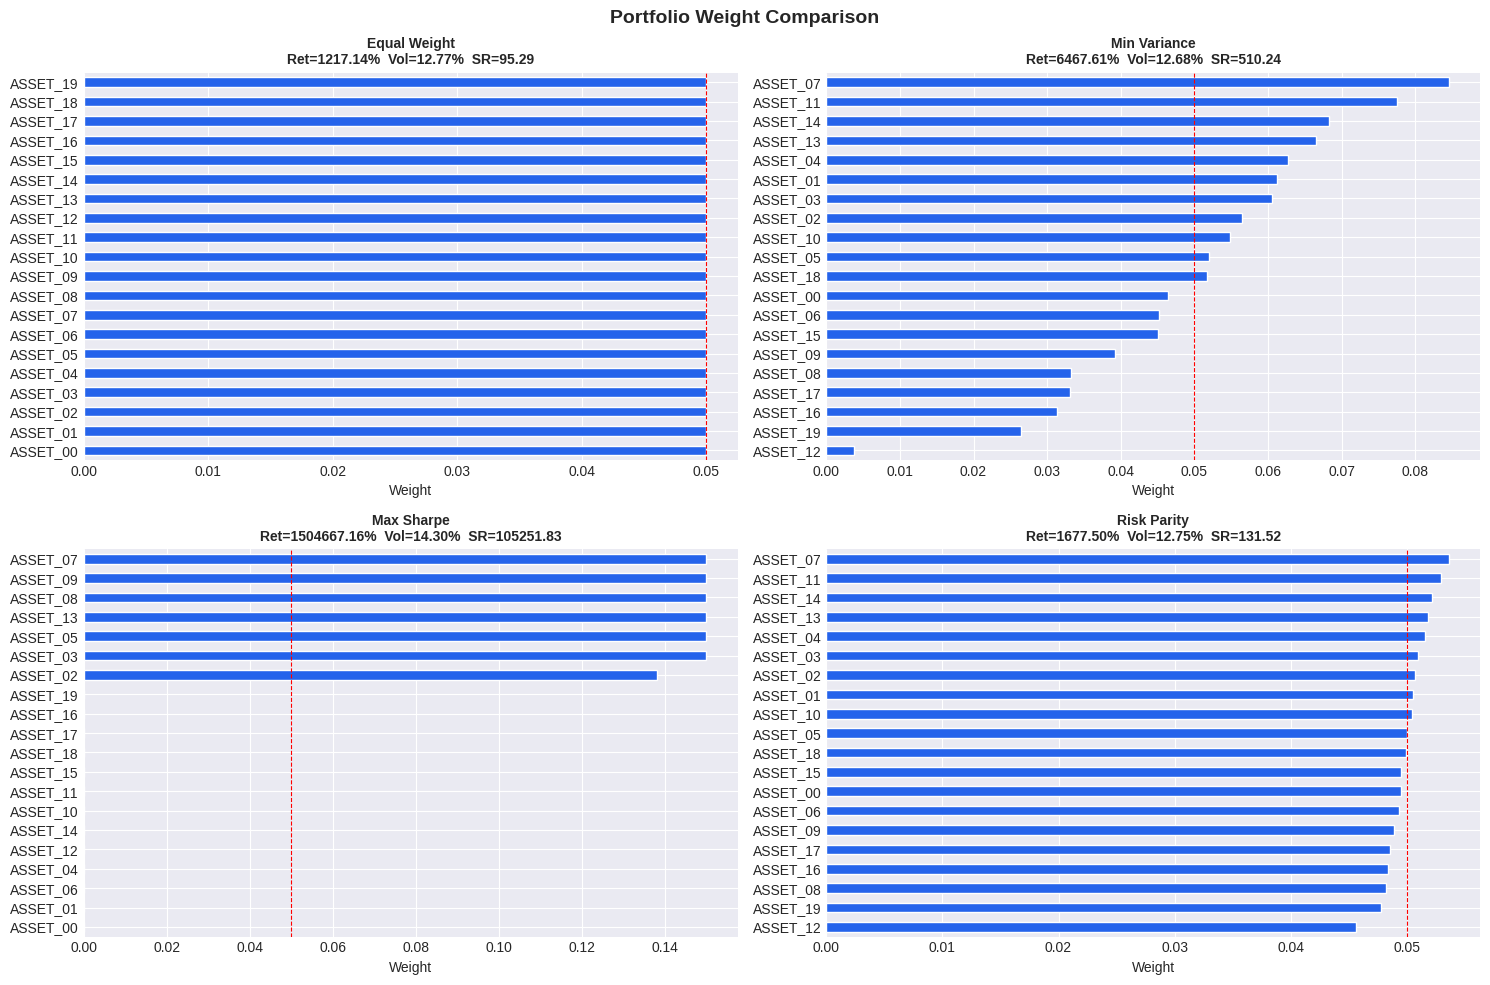

In [6]:
def risk_parity(Sigma, tol=1e-8, max_iter=500):
    """Equal risk contribution via iterative algorithm."""
    n  = Sigma.shape[0]
    w  = np.ones(n) / n
    for _ in range(max_iter):
        mrc = Sigma @ w
        rc  = w * mrc
        w_new = w * np.sqrt(1.0 / (n * rc / rc.sum() + tol))
        w_new /= w_new.sum()
        if np.max(np.abs(w_new - w)) < tol:
            break
        w = w_new
    return w

w_rp = risk_parity(Sigma)

# Risk contribution check
mrc = Sigma @ w_rp
rc  = w_rp * mrc
print("Risk Parity - Risk contributions (should be equal):")
print(pd.Series(rc / rc.sum(), index=assets).describe())

# Visualise portfolio weights side by side
port_names = ["Equal Weight", "Min Variance", "Max Sharpe", "Risk Parity"]
port_weights = [w_ew, w_mv, w_ms, w_rp]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (name, w) in zip(axes.ravel(), zip(port_names, port_weights)):
    pd.Series(w, index=assets).sort_values(ascending=True).plot.barh(
        ax=ax, color=COLORS[0], edgecolor="white"
    )
    ret, vol, sr = portfolio_stats(w, mu, Sigma)
    ax.set_title(f"{name}\nRet={ret:.2%}  Vol={vol:.2%}  SR={sr:.2f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Weight")
    ax.axvline(1/N_ASSETS, color="red", linestyle="--", linewidth=0.8)

plt.suptitle("Portfolio Weight Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Black-Litterman Model

In [8]:
def black_litterman(Sigma, w_mkt, views_P, views_Q, views_omega,
                    tau=0.05, risk_free=0.0):
    """
    Black-Litterman expected return computation.
    P: views matrix (K x N), Q: view returns (K,), Omega: view uncertainty (K x K)
    """
    pi = tau * Sigma @ w_mkt      # implied equilibrium returns (reverse-optimisation)
    M1 = np.linalg.inv(np.linalg.inv(tau * Sigma) + views_P.T @ np.linalg.inv(views_omega) @ views_P)
    M2 = np.linalg.inv(tau * Sigma) @ pi + views_P.T @ np.linalg.inv(views_omega) @ views_Q
    mu_bl = M1 @ M2
    Sigma_bl = Sigma + M1
    return mu_bl, Sigma_bl

# Market-cap-weight proxy
w_mkt = rng.dirichlet(np.ones(N_ASSETS))

# Two views: ASSET_00 outperforms by 2%, ASSET_01 underperforms by 1%
P = np.zeros((2, N_ASSETS))
P[0, 0]  =  1.0
P[1, 1]  = -1.0
Q = np.array([0.0002, -0.0001])   # daily return views
Omega = np.diag([0.0001, 0.0001])

# Define tau globally for use outside the function
tau = 0.05

mu_bl, Sigma_bl = black_litterman(Sigma, w_mkt, P, Q, Omega, tau=tau)
w_bl = max_sharpe(mu_bl, Sigma_bl)

comparison = pd.DataFrame({
    "Equilibrium Mu": tau * Sigma @ w_mkt * 252,
    "BL Mu":          mu_bl * 252,
    "BL Weight":      w_bl,
    "MS Weight":      w_ms,
}, index=assets)

print("Black-Litterman vs Equilibrium expected returns (top 5):")
display(comparison.sort_values("BL Weight", ascending=False).head(8).style
    .background_gradient(subset=["BL Weight"], cmap="Blues")
    .format("{:.4f}")
)


Black-Litterman vs Equilibrium expected returns (top 5):


,Equilibrium Mu,BL Mu,BL Weight,MS Weight
ASSET_00,0.0008,0.0057,0.1500,0.0000
ASSET_01,0.0008,0.0042,0.1500,0.0000
ASSET_19,0.0008,0.0028,0.1500,0.0000
ASSET_09,0.0009,0.0031,0.1500,0.1500
ASSET_17,0.0011,0.0032,0.1500,0.0000
ASSET_12,0.0011,0.0032,0.1500,0.0000
ASSET_08,0.0009,0.0029,0.1000,0.1500
ASSET_02,0.0009,0.0030,0.0000,0.1382


## 8. Constraint-Aware Optimisation

Constrained portfolio tracking error vs EW benchmark: 4.75%


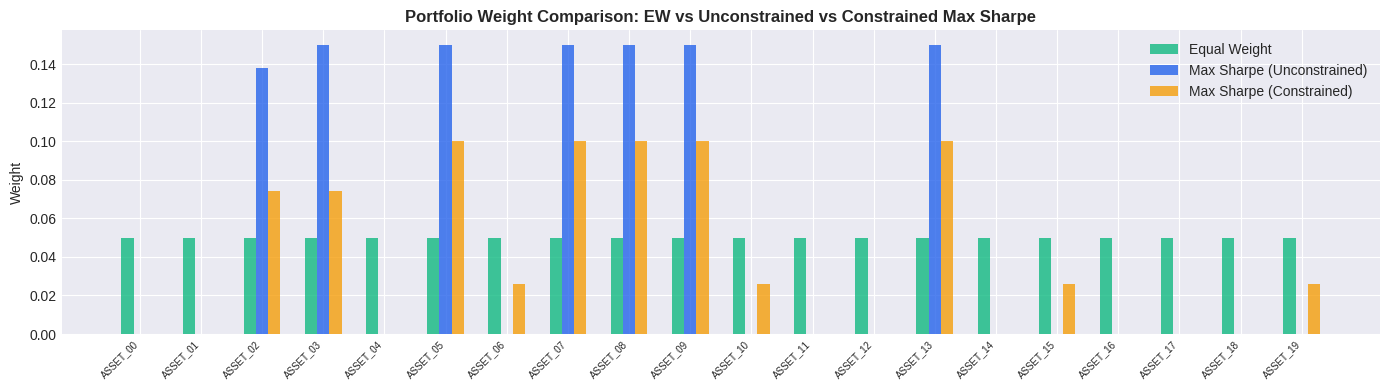

In [9]:
# Realistic institutional constraints:
# - Long-only, max 10% per asset
# - Sector neutrality (mock: first 10 assets = sector A, last 10 = sector B)
# - Max 55% in any sector
# - Tracking error <= 5% vs equal-weight benchmark

def constrained_max_sharpe(mu, Sigma, benchmark_w, max_te=0.05, max_pos=0.10):
    n = len(mu)
    def neg_sharpe(w):
        r, v, _ = portfolio_stats(w, mu, Sigma)
        return -r / v if v > 0 else 0

    def te_constraint(w):
        diff = w - benchmark_w
        te   = np.sqrt(diff @ Sigma @ diff * 252)
        return max_te - te   # must be >= 0

    constraints = [
        {"type": "eq",  "fun": lambda w: w.sum() - 1},
        {"type": "ineq","fun": te_constraint},
        {"type": "ineq","fun": lambda w: 0.55 - w[:10].sum()},   # sector A cap
        {"type": "ineq","fun": lambda w: 0.55 - w[10:].sum()},   # sector B cap
    ]
    bounds = [(0, max_pos)] * n
    w0     = benchmark_w.copy()
    result = minimize(neg_sharpe, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints,
                      options={"ftol": 1e-9, "maxiter": 2000})
    return result.x

w_constrained = constrained_max_sharpe(mu, Sigma, w_ew)

# Tracking error check
diff = w_constrained - w_ew
te   = np.sqrt(diff @ Sigma @ diff * 252)
print(f"Constrained portfolio tracking error vs EW benchmark: {te:.2%}")

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(N_ASSETS)
ax.bar(x - 0.2, w_ew,          width=0.2, label="Equal Weight", color=COLORS[2], alpha=0.8)
ax.bar(x,       w_ms,          width=0.2, label="Max Sharpe (Unconstrained)", color=COLORS[0], alpha=0.8)
ax.bar(x + 0.2, w_constrained, width=0.2, label="Max Sharpe (Constrained)", color=COLORS[3], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(assets, rotation=45, ha="right", fontsize=7)
ax.set_title("Portfolio Weight Comparison: EW vs Unconstrained vs Constrained Max Sharpe",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Weight")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Portfolio Backtesting

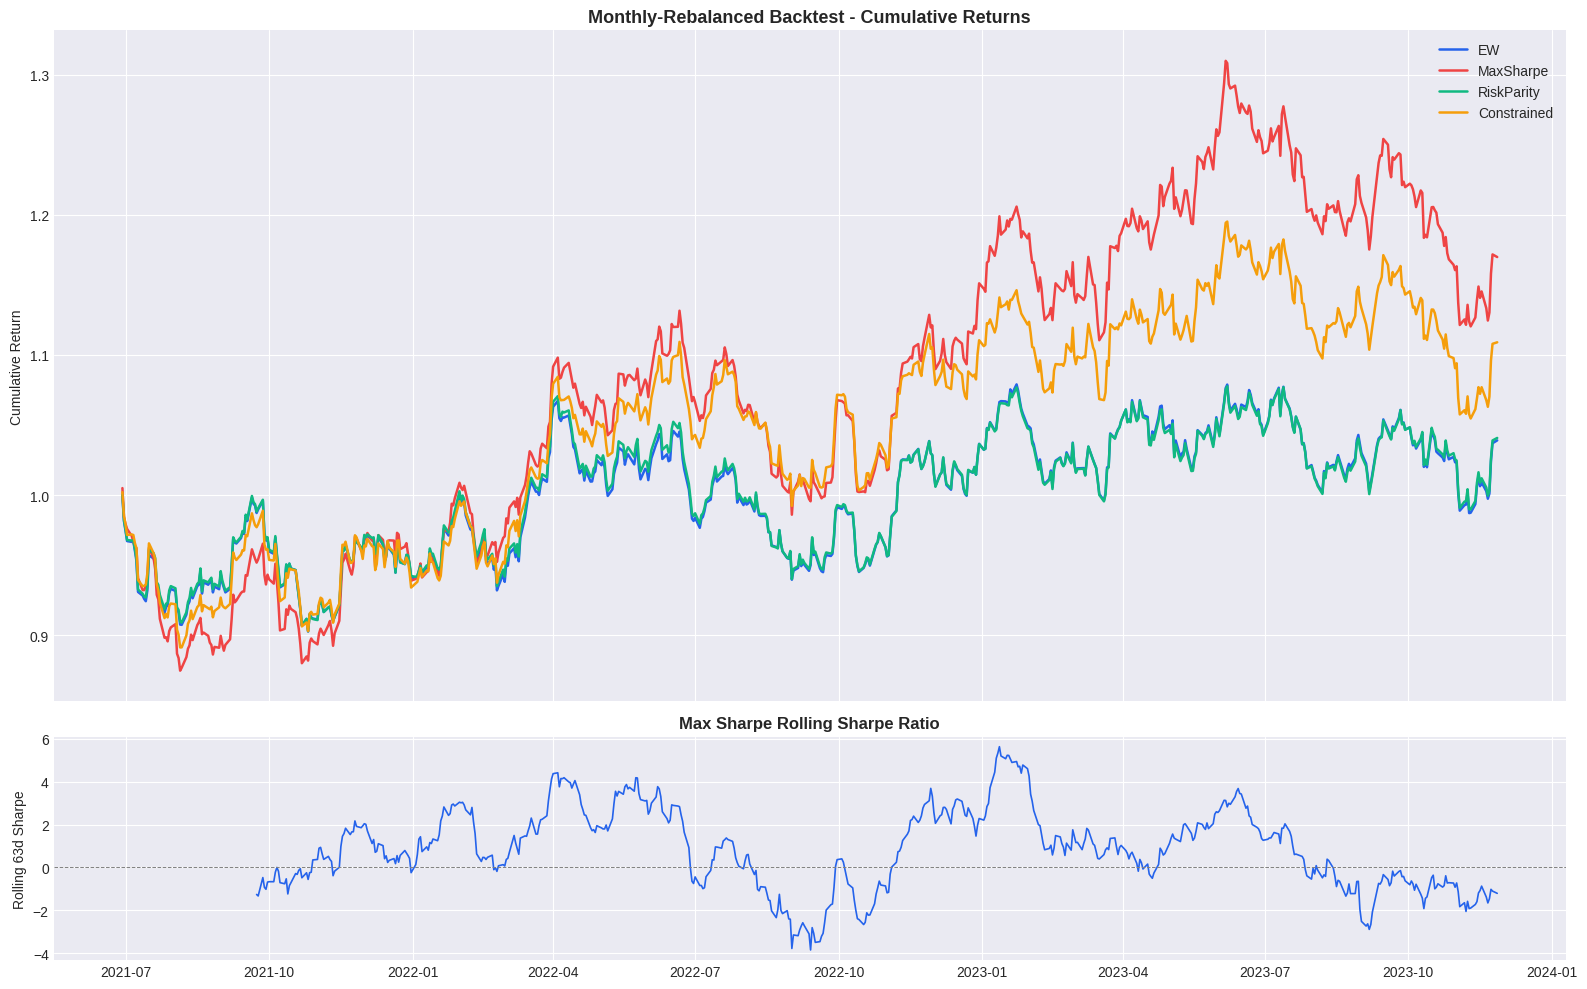

In [10]:
# Monthly rebalancing backtest: re-estimate covariance and alpha each period
rebal_freq = 21   # trading days
lookback   = 126  # 6-month covariance lookback

port_rets = {"EW": [], "MaxSharpe": [], "RiskParity": [], "Constrained": []}
port_dates = []

for t in range(lookback, N_DAYS, rebal_freq):
    window = returns_df.iloc[t - lookback:t]
    mu_t   = window.mean().values
    lw_t   = LedoitWolf()
    lw_t.fit(window)
    Sigma_t = lw_t.covariance_

    w_ew_t  = np.ones(N_ASSETS) / N_ASSETS
    try:
        w_ms_t  = max_sharpe(mu_t, Sigma_t)
        w_rp_t  = risk_parity(Sigma_t)
        w_cn_t  = constrained_max_sharpe(mu_t, Sigma_t, w_ew_t)
    except Exception:
        w_ms_t  = w_ew_t.copy()
        w_rp_t  = w_ew_t.copy()
        w_cn_t  = w_ew_t.copy()

    # Hold for next period
    end = min(t + rebal_freq, N_DAYS)
    period_rets = returns_df.iloc[t:end]
    for name, w in zip(port_rets.keys(), [w_ew_t, w_ms_t, w_rp_t, w_cn_t]):
        port_rets[name].extend((period_rets @ w).tolist())
    port_dates.extend(period_rets.index.tolist())

bt = pd.DataFrame(port_rets, index=pd.DatetimeIndex(port_dates)).sort_index()
cum_bt = (1 + bt).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

for col, color in zip(bt.columns, COLORS):
    axes[0].plot(cum_bt.index, cum_bt[col], linewidth=1.8, label=col, color=color)
axes[0].set_title("Monthly-Rebalanced Backtest - Cumulative Returns",
                   fontsize=13, fontweight="bold")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()

# Rolling Sharpe (63d)
roll_sr = bt["MaxSharpe"].rolling(63).apply(
    lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0, raw=True
)
axes[1].plot(roll_sr.index, roll_sr, color=COLORS[0], linewidth=1.2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.7)
axes[1].set_ylabel("Rolling 63d Sharpe")
axes[1].set_title("Max Sharpe Rolling Sharpe Ratio", fontweight="bold")
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


## 10. Performance Attribution

In [11]:
# Brinson-Hood-Beebower attribution: allocation + selection effects
def perf_summary(rets_col, label, rf=0.02/252):
    r = rets_col.dropna()
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sr      = (ann_ret - rf*252) / ann_vol if ann_vol > 0 else 0
    sortino = (ann_ret - rf*252) / (r[r<0].std() * np.sqrt(252)) if r[r<0].std() > 0 else 0
    cum     = (1 + r).prod() - 1
    mdd     = ((1+r).cumprod() / (1+r).cumprod().cummax() - 1).min()
    hit     = (r > 0).mean()
    return {"Strategy": label, "Ann. Return": ann_ret, "Ann. Vol": ann_vol,
            "Sharpe": sr, "Sortino": sortino, "Total Return": cum,
            "Max Drawdown": mdd, "Hit Rate": hit}

perf = pd.DataFrame([perf_summary(bt[col], col) for col in bt.columns]).set_index("Strategy")

display(perf.style
    .background_gradient(subset=["Sharpe","Ann. Return"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown"], cmap="RdYlGn_r")
    .format({
        "Ann. Return": "{:.2%}", "Ann. Vol": "{:.2%}", "Sharpe": "{:.2f}",
        "Sortino": "{:.2f}", "Total Return": "{:.2%}",
        "Max Drawdown": "{:.2%}", "Hit Rate": "{:.1%}",
    })
)


,Ann. Return,Ann. Vol,Sharpe,Sortino,Total Return,Max Drawdown,Hit Rate
Strategy,,,,,,,
EW,2.38%,13.04%,0.03,0.05,3.90%,-11.96%,49.0%
MaxSharpe,7.31%,14.43%,0.37,0.61,16.98%,-14.47%,49.7%
RiskParity,2.45%,13.06%,0.03,0.06,4.07%,-12.19%,48.4%
Constrained,5.06%,13.60%,0.23,0.37,10.90%,-11.75%,49.0%
